## Phase 1 - dataset audit only


In [1]:
from pathlib import Path
import json
import random
import os
import pandas as pd
from PIL import Image, ImageDraw

DATASET_ROOT = Path("Plant_stress")
SPLITS = {"train": "train", "valid": "valid", "test": "test"}
OUTPUT_ROOT = Path(".")


def display_name(name):
    return name.replace("_", " ").replace("-", " ").strip().title()


def write_json(path, data):
    path.write_text(json.dumps(data, indent=2), encoding="utf-8")


def open_image(path):
    with Image.open(path) as img:
        img.load()
        return img.size


if not DATASET_ROOT.exists():
    raise FileNotFoundError(f"Dataset root not found: {DATASET_ROOT}")

datasets = {}
audit_log = {
    "missing_files": [],
    "corrupt_images": [],
    "invalid_zero_hot": [],
    "invalid_multi_hot": [],
    "warnings": [],
}

class_columns = None
records = []
sizes = []
class_counts = {}

for split, folder in SPLITS.items():
    split_path = DATASET_ROOT / folder
    csv_path = split_path / "_classes.csv"
    if not split_path.exists():
        raise FileNotFoundError(f"Missing split folder: {split_path}")
    if not csv_path.exists():
        raise FileNotFoundError(f"Missing class CSV: {csv_path}")

    df = pd.read_csv(csv_path)
    discovered = [column for column in df.columns if column != "filename"]
    if class_columns is None:
        class_columns = discovered
        class_counts = {name: 0 for name in class_columns}
    elif discovered != class_columns:
        audit_log["warnings"].append(f"Class columns differ in {csv_path}")

    datasets[split] = df

    numeric_labels = df[class_columns].apply(pd.to_numeric, errors="coerce").fillna(0)
    for row_index, row in df.iterrows():
        values = numeric_labels.loc[row_index, class_columns]
        hot_count = int(values.sum())
        item = {
            "split": split,
            "row": int(row_index),
            "filename": str(row["filename"]),
        }
        if hot_count == 0:
            audit_log["invalid_zero_hot"].append(item)
            continue
        if hot_count > 1:
            audit_log["invalid_multi_hot"].append(item)
            continue

        class_name = values.idxmax()
        image_path = split_path / str(row["filename"])
        if not image_path.exists():
            audit_log["missing_files"].append({**item, "path": str(image_path)})
            continue
        if image_path.stat().st_size == 0:
            audit_log["corrupt_images"].append({**item, "path": str(image_path), "error": "zero-byte image"})
            continue

        try:
            width, height = open_image(image_path)
        except Exception as exc:
            audit_log["corrupt_images"].append({**item, "path": str(image_path), "error": str(exc)})
            continue

        class_counts[class_name] += 1
        sizes.append((width, height))
        records.append({"split": split, "class": class_name, "path": image_path, "width": width, "height": height})

train_dataset = datasets["train"]
valid_dataset = datasets["valid"]
test_dataset = datasets["test"]

total_images = sum(class_counts.values())
display_classes = [display_name(name) for name in class_columns]
display_lookup = dict(zip(class_columns, display_classes))



## Dataset Summary

In [3]:
dataset_summary = {
    "dataset_root": str(DATASET_ROOT),
    "train_path": str(DATASET_ROOT / "train"),
    "valid_path": str(DATASET_ROOT / "valid"),
    "test_path": str(DATASET_ROOT / "test"),
    "image_size_target": [224, 224],
    "recommended_model": "MobileNetV3Small",
    "num_classes": len(class_columns),
    "original_classes": class_columns,
    "display_classes": display_classes,
    "images_per_class": {display_lookup[name]: class_counts[name] for name in class_columns},
    "total_images": total_images,
}

split_counts = {split: len(df) for split, df in datasets.items()}
split_total = sum(split_counts.values())
split_ratios = {split: round((count / split_total) * 100, 2) if split_total else 0 for split, count in split_counts.items()}
split_warnings = []
if split_ratios["train"] < 60:
    split_warnings.append("Train split is below 60%")
if split_ratios["valid"] < 10:
    split_warnings.append("Validation split is below 10%")
if split_ratios["test"] < 10:
    split_warnings.append("Test split is below 10%")
audit_log["warnings"].extend(split_warnings)
split_report = {"counts": split_counts, "ratios_percent": split_ratios, "warnings": split_warnings}

widths = [width for width, _ in sizes]
heights = [height for _, height in sizes]
image_size_report = {
    "width": {
        "min": min(widths) if widths else 0,
        "max": max(widths) if widths else 0,
        "avg": round(sum(widths) / len(widths), 2) if widths else 0,
    },
    "height": {
        "min": min(heights) if heights else 0,
        "max": max(heights) if heights else 0,
        "avg": round(sum(heights) / len(heights), 2) if heights else 0,
    },
    "unique_resolution_count": len(set(sizes)),
}

largest_class = max(class_counts, key=class_counts.get) if class_counts else None
smallest_class = min(class_counts, key=class_counts.get) if class_counts else None
smallest_count = class_counts[smallest_class] if smallest_class else 0
imbalance_ratio = round(class_counts[largest_class] / smallest_count, 4) if smallest_count else 0
imbalance_warning = "Potential Class Imbalance" if imbalance_ratio > 2 else None
if imbalance_warning:
    audit_log["warnings"].append(imbalance_warning)

class_distribution = {
    "classes": {
        display_lookup[name]: {
            "count": class_counts[name],
            "percentage": round((class_counts[name] / total_images) * 100, 2) if total_images else 0,
        }
        for name in class_columns
    },
    "largest_class": display_lookup[largest_class] if largest_class else "",
    "smallest_class": display_lookup[smallest_class] if smallest_class else "",
    "imbalance_ratio": imbalance_ratio,
    "warning": imbalance_warning,
}

def make_distribution_chart(path):
    width, height = 900, 420
    margin = 70
    chart = Image.new("RGB", (width, height), "white")
    draw = ImageDraw.Draw(chart)
    max_count = max(class_counts.values()) if class_counts else 1
    bar_area = width - (margin * 2)
    bar_width = max(40, bar_area // max(1, len(class_columns)) - 25)
    colors = ["#2f7d32", "#f2a900", "#b23a48", "#3b6ea8"]
    draw.text((margin, 20), "Class Distribution", fill="black")
    for index, name in enumerate(class_columns):
        count = class_counts[name]
        x0 = margin + index * (bar_width + 25)
        x1 = x0 + bar_width
        bar_height = int((height - 150) * (count / max_count)) if max_count else 0
        y0 = height - margin - bar_height
        y1 = height - margin
        draw.rectangle((x0, y0, x1, y1), fill=colors[index % len(colors)])
        draw.text((x0, y0 - 20), str(count), fill="black")
        draw.text((x0, y1 + 8), display_lookup[name][:24], fill="black")
    chart.save(path)


def make_sample_grid(path):
    by_class = {name: [record for record in records if record["class"] == name] for name in class_columns}
    tile = 160
    label_h = 28
    cols = 9
    rows = max(1, len(class_columns))
    grid = Image.new("RGB", (cols * tile, rows * (tile + label_h)), "white")
    draw = ImageDraw.Draw(grid)
    rng = random.Random(42)
    for row_index, name in enumerate(class_columns):
        samples = by_class[name]
        sample_count = min(9, len(samples))
        chosen = rng.sample(samples, sample_count) if sample_count else []
        y = row_index * (tile + label_h)
        draw.text((6, y + 6), display_lookup[name], fill="black")
        for col_index, record in enumerate(chosen):
            with Image.open(record["path"]) as img:
                img = img.convert("RGB")
                img.thumbnail((tile, tile))
                x = col_index * tile
                paste_x = x + (tile - img.width) // 2
                paste_y = y + label_h + (tile - img.height) // 2
                grid.paste(img, (paste_x, paste_y))
    grid.save(path)


make_distribution_chart(OUTPUT_ROOT / "class_distribution.png")
make_sample_grid(OUTPUT_ROOT / "sample_grid.png")

issue_lines = []
for key in ["missing_files", "corrupt_images", "invalid_zero_hot", "invalid_multi_hot", "warnings"]:
    if audit_log[key]:
        issue_lines.append(f"- {key}: {len(audit_log[key])}")
if not issue_lines:
    issue_lines.append("- No blocking dataset issues detected by automated checks.")

report = f"""# Phase 1 Dataset Audit Report

## Dataset Overview
- Dataset root: `{DATASET_ROOT}`
- Total usable images: {total_images}
- Classes detected: {len(class_columns)}
- Original classes: {', '.join(class_columns)}
- Display classes: {', '.join(display_classes)}

## Class Summary
# Sử dụng dấu nháy đôi "" cho các khóa 'classes' và 'percentage' phía trong
{chr(10).join(f'- {display_lookup[name]}: {class_counts[name]} images ({class_distribution["classes"][display_lookup[name]]["percentage"]}%)' for name in class_columns)}
- Largest class: {class_distribution['largest_class']}
- Smallest class: {class_distribution['smallest_class']}
- Imbalance ratio: {imbalance_ratio}

## Split Summary
- Train: {split_counts['train']} rows ({split_ratios['train']}%)
- Validation: {split_counts['valid']} rows ({split_ratios['valid']}%)
- Test: {split_counts['test']} rows ({split_ratios['test']}%)

## Resolution Summary
- Width: min {image_size_report['width']['min']}, max {image_size_report['width']['max']}, avg {image_size_report['width']['avg']}
- Height: min {image_size_report['height']['min']}, max {image_size_report['height']['max']}, avg {image_size_report['height']['avg']}
- Unique resolutions: {image_size_report['unique_resolution_count']}

## Potential Issues
{chr(10).join(issue_lines)}

## Recommendations
- Review `sample_grid.png` manually for suspicious labels before training.
- Reuse `dataset_summary.json` metadata in later phases.
- Address any entries in `audit_log.json` before model training.
"""

write_json(OUTPUT_ROOT / "dataset_summary.json", dataset_summary)
write_json(OUTPUT_ROOT / "image_size_report.json", image_size_report)
write_json(OUTPUT_ROOT / "split_report.json", split_report)
write_json(OUTPUT_ROOT / "class_distribution.json", class_distribution)
write_json(OUTPUT_ROOT / "audit_log.json", audit_log)
(OUTPUT_ROOT / "dataset_report.md").write_text(report, encoding="utf-8")

print("Phase 1 dataset audit complete.")
print("Generated: dataset_summary.json, image_size_report.json, split_report.json, class_distribution.json, audit_log.json, class_distribution.png, sample_grid.png, dataset_report.md")


Phase 1 dataset audit complete.
Generated: dataset_summary.json, image_size_report.json, split_report.json, class_distribution.json, audit_log.json, class_distribution.png, sample_grid.png, dataset_report.md


## Phase 2 - TensorFlow data pipeline only


Found 3641 files belonging to 3 classes.
Found 461 files belonging to 3 classes.
Found 469 files belonging to 3 classes.
train images (32, 224, 224, 3) labels (32, 3)
valid images (32, 224, 224, 3) labels (32, 3)
test images (32, 224, 224, 3) labels (32, 3)
Class names: ['Critical Stress', 'Healthy', 'Non-Critical Stress']
Image counts: {'train': 3641, 'valid': 461, 'test': 469}
Batch counts: {'train': 114, 'valid': 15, 'test': 15}


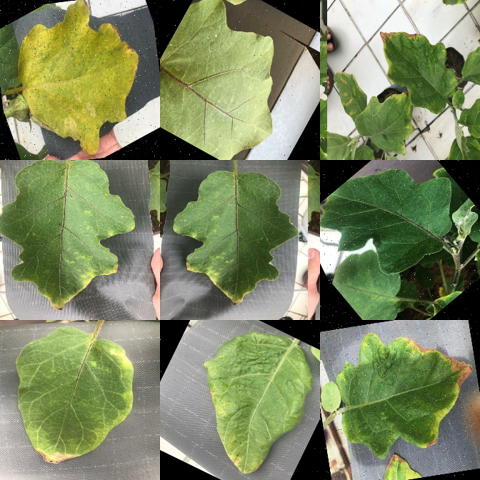

images.shape: (32, 224, 224, 3)
labels.shape: (32, 3)
dtype: float32
pixel_range: (0.0, 1.0)
Phase 2 data pipeline complete. Generated pipeline_config.json and pipeline_stats.json.


In [5]:
# Section 1 - Load Dependencies
from pathlib import Path
import json
import math
import os
import re
import shutil

import pandas as pd
from IPython.display import display
from PIL import Image, ImageDraw

try:
    import tensorflow as tf
except ImportError:
    raise ImportError("TensorFlow is not installed. Install it before running Phase 2.")


# Section 2 - Load Phase 1 Metadata
metadata_path = Path("dataset_summary.json")
if not metadata_path.exists():
    raise FileNotFoundError("dataset_summary.json not found. Run Phase 1 first.")

metadata = json.loads(metadata_path.read_text(encoding="utf-8"))
dataset_root = Path(metadata["dataset_root"])
source_paths = {
    "train": Path(metadata["train_path"]),
    "valid": Path(metadata["valid_path"]),
    "test": Path(metadata["test_path"]),
}
for split, path in source_paths.items():
    if not path.exists():
        raise FileNotFoundError(f"{split} path not found: {path}")


# Section 3 - Define Pipeline Configuration
IMG_HEIGHT, IMG_WIDTH = metadata.get("image_size_target", [224, 224])
BATCH_SIZE = 32
SEED = 42
GENERATED_ROOT = Path("pipeline_data")


def display_name(name):
    parts = re.split(r"([\s_-]+)", str(name).strip())
    return "".join(part.capitalize() if part.strip() and not part.isspace() else part for part in parts).replace("_", " ")


def safe_dir_name(name):
    return re.sub(r"[^A-Za-z0-9._ -]+", "", name).strip().replace(" ", "_")


def read_class_columns(csv_path):
    columns = list(pd.read_csv(csv_path, nrows=0).columns)
    return [column for column in columns if column != "filename"]


original_class_names = read_class_columns(source_paths["train"] / "_classes.csv")
for split, path in source_paths.items():
    split_classes = read_class_columns(path / "_classes.csv")
    if split_classes != original_class_names:
        raise ValueError(f"Class columns in {split} do not match train split.")

class_names = [display_name(name) for name in original_class_names]
if len(class_names) != int(metadata["num_classes"]):
    raise ValueError("CSV class count does not match dataset_summary.json num_classes.")


# Section 4 - Create TensorFlow Datasets
if GENERATED_ROOT.exists():
    shutil.rmtree(GENERATED_ROOT)

image_counts = {"train": 0, "valid": 0, "test": 0}
skipped_labels = {"zero_hot": 0, "multi_hot": 0, "missing_files": 0}

for split, source_path in source_paths.items():
    df = pd.read_csv(source_path / "_classes.csv")
    labels = df[original_class_names].apply(pd.to_numeric, errors="coerce").fillna(0)
    for class_name in class_names:
        (GENERATED_ROOT / split / safe_dir_name(class_name)).mkdir(parents=True, exist_ok=True)

    for row_index, row in df.iterrows():
        row_labels = labels.loc[row_index, original_class_names]
        hot_count = int(row_labels.sum())
        if hot_count == 0:
            skipped_labels["zero_hot"] += 1
            continue
        if hot_count > 1:
            skipped_labels["multi_hot"] += 1
            continue

        class_index = original_class_names.index(row_labels.idxmax())
        source_file = source_path / str(row["filename"])
        if not source_file.exists():
            skipped_labels["missing_files"] += 1
            continue

        target_file = GENERATED_ROOT / split / safe_dir_name(class_names[class_index]) / source_file.name
        try:
            os.link(source_file, target_file)
        except OSError:
            shutil.copy2(source_file, target_file)
        image_counts[split] += 1

loader_kwargs = {
    "class_names": [safe_dir_name(name) for name in class_names],
    "label_mode": "categorical",
    "image_size": (IMG_HEIGHT, IMG_WIDTH),
    "batch_size": BATCH_SIZE,
    "seed": SEED,
}
raw_train_ds = tf.keras.utils.image_dataset_from_directory(GENERATED_ROOT / "train", shuffle=True, **loader_kwargs)
raw_val_ds = tf.keras.utils.image_dataset_from_directory(GENERATED_ROOT / "valid", shuffle=False, **loader_kwargs)
raw_test_ds = tf.keras.utils.image_dataset_from_directory(GENERATED_ROOT / "test", shuffle=False, **loader_kwargs)


# Section 5 - Verify Dataset Structure
train_batches = tf.data.experimental.cardinality(raw_train_ds).numpy().item()
valid_batches = tf.data.experimental.cardinality(raw_val_ds).numpy().item()
test_batches = tf.data.experimental.cardinality(raw_test_ds).numpy().item()

for name, ds in [("train", raw_train_ds), ("valid", raw_val_ds), ("test", raw_test_ds)]:
    images, labels = next(iter(ds))
    print(name, "images", images.shape, "labels", labels.shape)
print("Class names:", class_names)
print("Image counts:", image_counts)
print("Batch counts:", {"train": train_batches, "valid": valid_batches, "test": test_batches})


# Section 6 - Normalize Images
normalization = tf.keras.layers.Rescaling(1.0 / 255)
train_ds = raw_train_ds.map(lambda images, labels: (normalization(images), labels), num_parallel_calls=tf.data.AUTOTUNE)
val_ds = raw_val_ds.map(lambda images, labels: (normalization(images), labels), num_parallel_calls=tf.data.AUTOTUNE)
test_ds = raw_test_ds.map(lambda images, labels: (normalization(images), labels), num_parallel_calls=tf.data.AUTOTUNE)


# Section 7 - Create Augmentation Pipeline
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal", seed=SEED),
    tf.keras.layers.RandomRotation(0.05, seed=SEED),
    tf.keras.layers.RandomZoom(0.1, seed=SEED),
], name="data_augmentation")
augmented_train_ds = train_ds.map(lambda images, labels: (data_augmentation(images, training=True), labels), num_parallel_calls=tf.data.AUTOTUNE)


# Section 8 - Optimize Pipeline
train_ds = train_ds.cache().prefetch(tf.data.AUTOTUNE)
augmented_train_ds = augmented_train_ds.cache().prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.cache().prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.cache().prefetch(tf.data.AUTOTUNE)

pipeline_config = {
    "dataset_root": str(dataset_root),
    "source_paths": {split: str(path) for split, path in source_paths.items()},
    "generated_paths": {split: str(GENERATED_ROOT / split) for split in source_paths},
    "class_names": class_names,
    "class_directory_names": [safe_dir_name(name) for name in class_names],
    "image_size": [IMG_HEIGHT, IMG_WIDTH],
    "batch_size": BATCH_SIZE,
    "seed": SEED,
    "train_batches": train_batches,
    "valid_batches": valid_batches,
    "test_batches": test_batches,
    "skipped_labels": skipped_labels,
}
pipeline_stats = {
    "num_classes": len(class_names),
    "train_images": image_counts["train"],
    "valid_images": image_counts["valid"],
    "test_images": image_counts["test"],
    "train_batches": train_batches,
    "valid_batches": valid_batches,
    "test_batches": test_batches,
    "batch_size": BATCH_SIZE,
    "image_size": [IMG_HEIGHT, IMG_WIDTH],
}
Path("pipeline_config.json").write_text(json.dumps(pipeline_config, indent=2), encoding="utf-8")
Path("pipeline_stats.json").write_text(json.dumps(pipeline_stats, indent=2), encoding="utf-8")


# Section 9 - Visual Inspection
sample_images, sample_labels = next(iter(train_ds))
sample_images = sample_images[:9]
tile = 160
grid = Image.new("RGB", (3 * tile, 3 * tile), "white")
for index, image_tensor in enumerate(sample_images):
    image = Image.fromarray((image_tensor.numpy() * 255).astype("uint8"))
    image.thumbnail((tile, tile))
    x = (index % 3) * tile + (tile - image.width) // 2
    y = (index // 3) * tile + (tile - image.height) // 2
    grid.paste(image, (x, y))
display(grid)


# Section 10 - Pipeline Validation
images, labels = next(iter(val_ds))
min_pixel = float(tf.reduce_min(images).numpy())
max_pixel = float(tf.reduce_max(images).numpy())
print("images.shape:", images.shape)
print("labels.shape:", labels.shape)
print("dtype:", images.dtype.name)
print("pixel_range:", (min_pixel, max_pixel))
assert images.dtype == tf.float32
assert 0.0 <= min_pixel <= 1.0
assert 0.0 <= max_pixel <= 1.0

print("Phase 2 data pipeline complete. Generated pipeline_config.json and pipeline_stats.json.")


## Phase 3.1 - Load Dependencies


In [1]:
from pathlib import Path
import json

import matplotlib.pyplot as plt

try:
    import tensorflow as tf
except ImportError:
    raise ImportError("TensorFlow is not installed. Install it before running Phase 3.")

SEED = 42
tf.keras.utils.set_random_seed(SEED)
PHASE3_DIR = Path("artifacts/phase3")
PHASE3_DIR.mkdir(parents=True, exist_ok=True)


## Phase 3.2 - Load Phase 2 Artifacts


In [2]:
pipeline_config = json.loads(Path("pipeline_config.json").read_text(encoding="utf-8"))
pipeline_stats = json.loads(Path("pipeline_stats.json").read_text(encoding="utf-8"))

class_names = pipeline_config["class_names"]
class_directory_names = pipeline_config["class_directory_names"]
IMG_HEIGHT, IMG_WIDTH = pipeline_config["image_size"]
BATCH_SIZE = pipeline_config["batch_size"]
NUM_CLASSES = pipeline_stats["num_classes"]

print("Classes:", class_names)
print("Image size:", (IMG_HEIGHT, IMG_WIDTH))
print("Batch size:", BATCH_SIZE)
print("Stats:", pipeline_stats)


Classes: ['Critical Stress', 'Healthy', 'Non-Critical Stress']
Image size: (224, 224)
Batch size: 32
Stats: {'num_classes': 3, 'train_images': 3641, 'valid_images': 461, 'test_images': 469, 'train_batches': 114, 'valid_batches': 15, 'test_batches': 15, 'batch_size': 32, 'image_size': [224, 224]}


## Phase 3.3 - Verify Datasets


In [3]:
loader_kwargs = {
    "class_names": class_directory_names,
    "label_mode": "categorical",
    "image_size": (IMG_HEIGHT, IMG_WIDTH),
    "batch_size": BATCH_SIZE,
    "seed": SEED,
}
raw_train_ds = tf.keras.utils.image_dataset_from_directory(pipeline_config["generated_paths"]["train"], shuffle=True, **loader_kwargs)
raw_val_ds = tf.keras.utils.image_dataset_from_directory(pipeline_config["generated_paths"]["valid"], shuffle=False, **loader_kwargs)
raw_test_ds = tf.keras.utils.image_dataset_from_directory(pipeline_config["generated_paths"]["test"], shuffle=False, **loader_kwargs)

normalization = tf.keras.layers.Rescaling(1.0 / 255)
train_ds = raw_train_ds.map(lambda images, labels: (normalization(images), labels), num_parallel_calls=tf.data.AUTOTUNE)
val_ds = raw_val_ds.map(lambda images, labels: (normalization(images), labels), num_parallel_calls=tf.data.AUTOTUNE)
test_ds = raw_test_ds.map(lambda images, labels: (normalization(images), labels), num_parallel_calls=tf.data.AUTOTUNE)

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal", seed=SEED),
    tf.keras.layers.RandomRotation(0.05, seed=SEED),
    tf.keras.layers.RandomZoom(0.1, seed=SEED),
], name="data_augmentation")
augmented_train_ds = train_ds.map(lambda images, labels: (data_augmentation(images, training=True), labels), num_parallel_calls=tf.data.AUTOTUNE)

train_ds = train_ds.cache().prefetch(tf.data.AUTOTUNE)
augmented_train_ds = augmented_train_ds.cache().prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.cache().prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.cache().prefetch(tf.data.AUTOTUNE)

for name, ds in [("train_ds", train_ds), ("augmented_train_ds", augmented_train_ds), ("val_ds", val_ds), ("test_ds", test_ds)]:
    images, labels = next(iter(ds))
    print(name, images.shape, labels.shape, images.dtype)


Found 3641 files belonging to 3 classes.
Found 461 files belonging to 3 classes.
Found 469 files belonging to 3 classes.
train_ds (32, 224, 224, 3) (32, 3) <dtype: 'float32'>
augmented_train_ds (32, 224, 224, 3) (32, 3) <dtype: 'float32'>
val_ds (32, 224, 224, 3) (32, 3) <dtype: 'float32'>
test_ds (32, 224, 224, 3) (32, 3) <dtype: 'float32'>


## Phase 3.4 - Build Baseline Model


In [4]:
DENSE_UNITS = 128
DROPOUT = 0.2

base_model = tf.keras.applications.MobileNetV3Small(
    weights="imagenet",
    include_top=False,
    include_preprocessing=False,
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
)
base_model.trainable = False

model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(DENSE_UNITS, activation="relu"),
    tf.keras.layers.Dropout(DROPOUT),
    tf.keras.layers.Dense(NUM_CLASSES, activation="softmax"),
], name="moss_baseline_mobilenetv3small")


4334752/4334752 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


## Phase 3.5 - Review Model


In [5]:
model.summary()
print("Total parameters:", model.count_params())
print("Trainable parameters:", sum(tf.keras.backend.count_params(w) for w in model.trainable_weights))
print("Non-trainable parameters:", sum(tf.keras.backend.count_params(w) for w in model.non_trainable_weights))


Model: "moss_baseline_mobilenetv3small"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ MobileNetV3Small (Functional)   │ (None, 7, 7, 576)      │       939,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 576)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,013,363 (3.87 MB)

 Trainable params: 74,243 (290.01 KB)

 Non-trainable params: 939,120 (3.58 MB)

Total parameters: 1013363
Trainable parameters: 74243
Non-trainable parameters: 939120


## Phase 3.6 - Compile Model


In [6]:
LEARNING_RATE = 1e-4
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss=tf.keras.losses.CategoricalCrossentropy(),
    metrics=["accuracy"],
)


## Phase 3.7 - Configure Callbacks


In [7]:
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        PHASE3_DIR / "baseline_model.keras",
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        mode="max",
        patience=3,
        restore_best_weights=True,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
    ),
]


## Phase 3.8 - Train Model


In [8]:
EPOCHS = 15
history = model.fit(
    augmented_train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
)


Epoch 1/15
114/114 ━━━━━━━━━━━━━━━━━━━━ 17s 112ms/step - accuracy: 0.4988 - loss: 1.0292 - val_accuracy: 0.6443 - val_loss: 0.7930 - learning_rate: 1.0000e-04
Epoch 2/15
114/114 ━━━━━━━━━━━━━━━━━━━━ 11s 94ms/step - accuracy: 0.6380 - loss: 0.8098 - val_accuracy: 0.7397 - val_loss: 0.6532 - learning_rate: 1.0000e-04
Epoch 3/15
114/114 ━━━━━━━━━━━━━━━━━━━━ 13s 110ms/step - accuracy: 0.6888 - loss: 0.7198 - val_accuracy: 0.7636 - val_loss: 0.5792 - learning_rate: 1.0000e-04
Epoch 4/15
114/114 ━━━━━━━━━━━━━━━━━━━━ 13s 115ms/step - accuracy: 0.7380 - loss: 0.6492 - val_accuracy: 0.7852 - val_loss: 0.5330 - learning_rate: 1.0000e-04
Epoch 5/15
114/114 ━━━━━━━━━━━━━━━━━━━━ 14s 122ms/step - accuracy: 0.7465 - loss: 0.6077 - val_accuracy: 0.7918 - val_loss: 0.5008 - learning_rate: 1.0000e-04
Epoch 6/15
114/114 ━━━━━━━━━━━━━━━━━━━━ 13s 115ms/step - accuracy: 0.7748 - loss: 0.5754 - val_accuracy: 0.8113 - val_loss: 0.4728 - learning_rate: 1.0000e-04
Epoch 7/15
114/114 ━━━━━━━━━━━━━━━━━━━━ 20s 111

## Phase 3.9 - Visualize Training


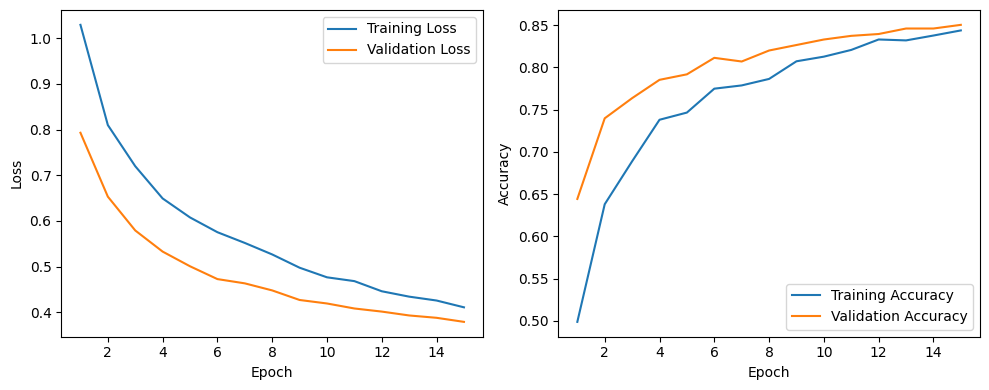

In [10]:
history_data = history.history
epochs_ran = range(1, len(history_data["loss"]) + 1)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_ran, history_data["loss"], label="Training Loss")
plt.plot(epochs_ran, history_data["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_ran, history_data["accuracy"], label="Training Accuracy")
plt.plot(epochs_ran, history_data["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

plt.close()


## Phase 3.10 - Training Summary


In [11]:
best_index = max(range(len(history_data["val_accuracy"])), key=lambda index: history_data["val_accuracy"][index])
training_summary = {
    "seed": SEED,
    "epochs_requested": EPOCHS,
    "epochs_completed": len(history_data["loss"]),
    "best_epoch": best_index + 1,
    "best_val_accuracy": float(history_data["val_accuracy"][best_index]),
    "best_val_loss": float(history_data["val_loss"][best_index]),
    "final_train_accuracy": float(history_data["accuracy"][-1]),
    "final_val_accuracy": float(history_data["val_accuracy"][-1]),
}
model_metadata = {
    "architecture": "MobileNetV3Small",
    "weights": "imagenet",
    "frozen_backbone": True,
    "dense_units": DENSE_UNITS,
    "dropout": DROPOUT,
    "learning_rate": LEARNING_RATE,
    "batch_size": BATCH_SIZE,
    "image_size": [IMG_HEIGHT, IMG_WIDTH],
    "class_names": class_names,
}

(PHASE3_DIR / "training_summary.json").write_text(json.dumps(training_summary, indent=2), encoding="utf-8")
(PHASE3_DIR / "model_metadata.json").write_text(json.dumps(model_metadata, indent=2), encoding="utf-8")
model.save(PHASE3_DIR / "baseline_model.keras")

print("Training summary:", training_summary)
print("Saved Phase 3 artifacts to", PHASE3_DIR)


Training summary: {'seed': 42, 'epochs_requested': 15, 'epochs_completed': 15, 'best_epoch': 15, 'best_val_accuracy': 0.8503254055976868, 'best_val_loss': 0.37915778160095215, 'final_train_accuracy': 0.843724250793457, 'final_val_accuracy': 0.8503254055976868}
Saved Phase 3 artifacts to artifacts\phase3


# Phase 5 — Model Evaluation


## Phase 5.1 - Load Final Model & Test Dataset


In [ ]:
from pathlib import Path
import json

import tensorflow as tf
import numpy as np

SEED = 42
PHASE3_DIR = Path("artifacts/phase3")
PHASE5_DIR = Path("artifacts/phase5")
PHASE5_DIR.mkdir(parents=True, exist_ok=True)

pipeline_config = json.loads(Path("pipeline_config.json").read_text(encoding="utf-8"))
class_names = pipeline_config["class_names"]
class_directory_names = pipeline_config["class_directory_names"]
IMG_HEIGHT, IMG_WIDTH = pipeline_config["image_size"]
BATCH_SIZE = pipeline_config["batch_size"]

model = tf.keras.models.load_model(PHASE3_DIR / "baseline_model.keras")

raw_test_ds = tf.keras.utils.image_dataset_from_directory(
    pipeline_config["generated_paths"]["test"],
    class_names=class_directory_names,
    label_mode="categorical",
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    seed=SEED,
    shuffle=False,
)
normalization = tf.keras.layers.Rescaling(1.0 / 255)
test_ds = raw_test_ds.map(
    lambda images, labels: (normalization(images), labels),
    num_parallel_calls=tf.data.AUTOTUNE,
).cache().prefetch(tf.data.AUTOTUNE)

images, labels = next(iter(test_ds))
print("test_ds shape:", images.shape, labels.shape, images.dtype)
print("Class names:", class_names)
print("Model loaded from:", PHASE3_DIR / "baseline_model.keras")


Found 469 files belonging to 3 classes.
test_ds shape: (32, 224, 224, 3) (32, 3) <dtype: 'float32'>
Class names: ['Critical Stress', 'Healthy', 'Non-Critical Stress']
Model loaded from: artifacts\phase3\baseline_model.keras


## Phase 5.2 - Test Set Evaluation


In [40]:
test_loss, test_accuracy = model.evaluate(test_ds, verbose=1)
print(f"Test Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")


15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 72ms/step - accuracy: 0.8486 - loss: 0.4070
Test Loss:     0.4070
Test Accuracy: 0.8486


## Phase 5.3 - Generate Predictions


In [41]:
# ponytail: collect y_true, y_pred, y_prob in one pass
y_prob = model.predict(test_ds)
y_pred = np.argmax(y_prob, axis=1)
y_true = np.concatenate([np.argmax(labels.numpy(), axis=1) for _, labels in test_ds])

print(f"Samples: {len(y_true)}, Predictions: {len(y_pred)}")
print(f"Classes: {class_names}")


15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 89ms/step
Samples: 469, Predictions: 469
Classes: ['Critical Stress', 'Healthy', 'Non-Critical Stress']


## Phase 5.4 - Confusion Matrix


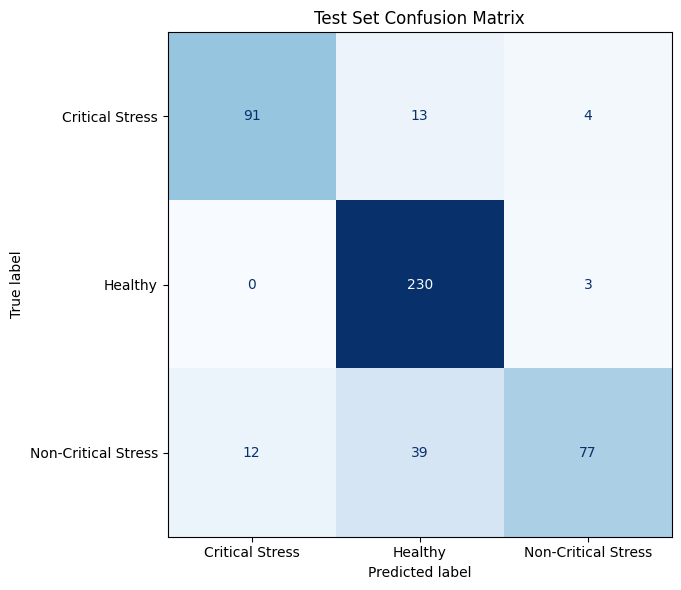

In [44]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Test Set Confusion Matrix")
plt.tight_layout()
plt.show()


## Phase 5.5 - Classification Report


In [45]:
from sklearn.metrics import classification_report, f1_score

print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

macro_f1 = f1_score(y_true, y_pred, average="macro")
weighted_f1 = f1_score(y_true, y_pred, average="weighted")
print(f"Macro F1:    {macro_f1:.4f}")
print(f"Weighted F1: {weighted_f1:.4f}")


                     precision    recall  f1-score   support

    Critical Stress     0.8835    0.8426    0.8626       108
            Healthy     0.8156    0.9871    0.8932       233
Non-Critical Stress     0.9167    0.6016    0.7264       128

           accuracy                         0.8486       469
          macro avg     0.8719    0.8104    0.8274       469
       weighted avg     0.8588    0.8486    0.8406       469

Macro F1:    0.8274
Weighted F1: 0.8406


## Phase 5.6 - Error Analysis


Total misclassified: 71 / 469


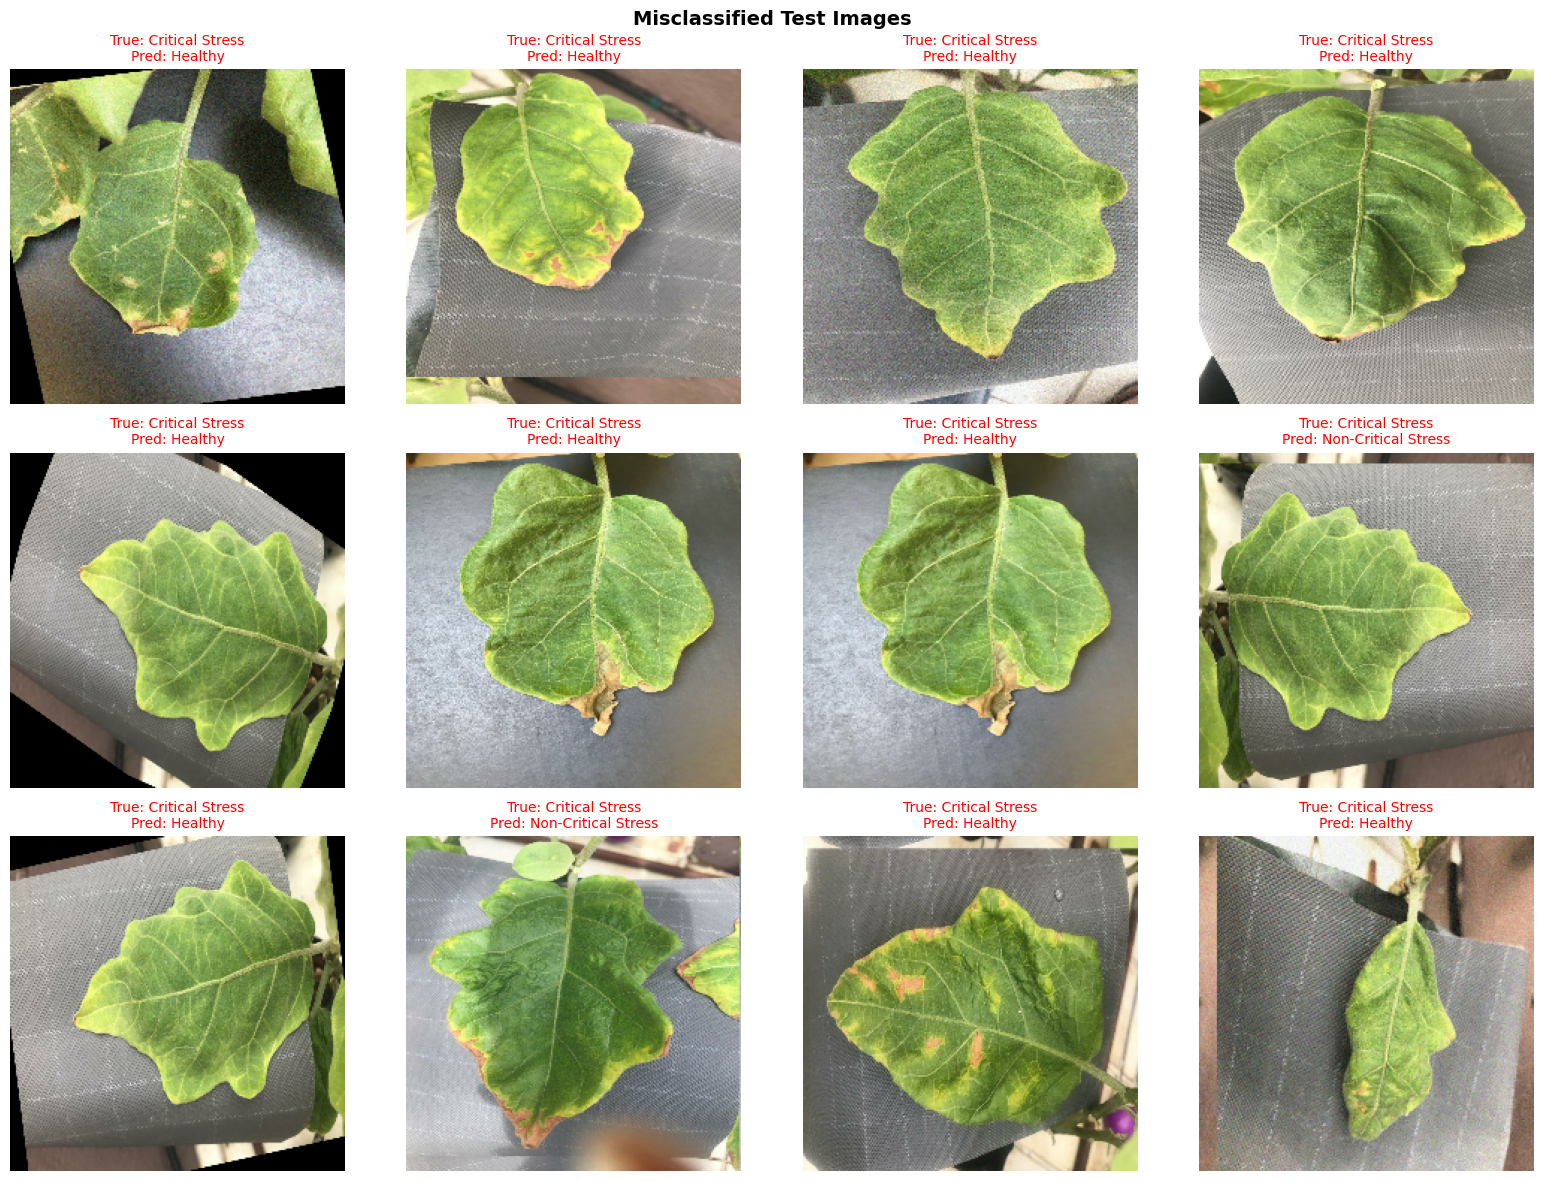

In [46]:
# ponytail: show up to 12 misclassified images in a grid
misclassified_idx = np.where(y_true != y_pred)[0]
n_show = min(12, len(misclassified_idx))
print(f"Total misclassified: {len(misclassified_idx)} / {len(y_true)}")

if n_show > 0:
    # Gather all test images (unnormalized for display)
    all_images = np.concatenate([imgs.numpy() for imgs, _ in raw_test_ds])
    cols = min(4, n_show)
    rows = (n_show + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    axes = np.array(axes).flatten()
    for i in range(n_show):
        idx = misclassified_idx[i]
        axes[i].imshow(all_images[idx].astype("uint8"))
        axes[i].set_title(
            f"True: {class_names[y_true[idx]]}\nPred: {class_names[y_pred[idx]]}",
            fontsize=10, color="red",
        )
        axes[i].axis("off")
    for i in range(n_show, len(axes)):
        axes[i].axis("off")
    plt.suptitle("Misclassified Test Images", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()
else:
    print("No misclassified images!")


## Phase 5.7 - Save Evaluation Summary


In [47]:
evaluation_summary = {
    "test_loss": float(test_loss),
    "test_accuracy": float(test_accuracy),
    "macro_f1": float(macro_f1),
    "weighted_f1": float(weighted_f1),
    "class_names": class_names,
}

summary_path = PHASE5_DIR / "evaluation_summary.json"
summary_path.write_text(json.dumps(evaluation_summary, indent=2), encoding="utf-8")
print("Evaluation summary:")
print(json.dumps(evaluation_summary, indent=2))
print(f"Saved to {summary_path}")


Evaluation summary:
{
  "test_loss": 0.40699872374534607,
  "test_accuracy": 0.8486140966415405,
  "macro_f1": 0.8273927398469766,
  "weighted_f1": 0.8406269403712282,
  "class_names": [
    "Critical Stress",
    "Healthy",
    "Non-Critical Stress"
  ]
}
Saved to artifacts\phase5\evaluation_summary.json
